Peguei como base esta competição: https://www.kaggle.com/code/yiitcancokun/risk-prediction-with-tree-classifiers/notebook

In [1]:
!pip install codecarbon

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, brier_score_loss, roc_auc_score
)
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
import time

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from codecarbon import EmissionsTracker

In [3]:
dataset = pd.read_csv('/content/drive/MyDrive/Pesquisa 2/Código/german_credit_data/german_credit_data.csv')

In [4]:
dataset

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
995,995,31,female,1,own,little,NaN,1736,12,furniture/equipment,good
996,996,40,male,3,own,little,little,3857,30,car,good
997,997,38,male,2,own,little,NaN,804,12,radio/TV,good
998,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [5]:
dataset.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [6]:
dataset['Risk']

,Risk
0,good
1,bad
2,good
3,good
4,bad
...,...
995,good
996,good
997,good
998,bad


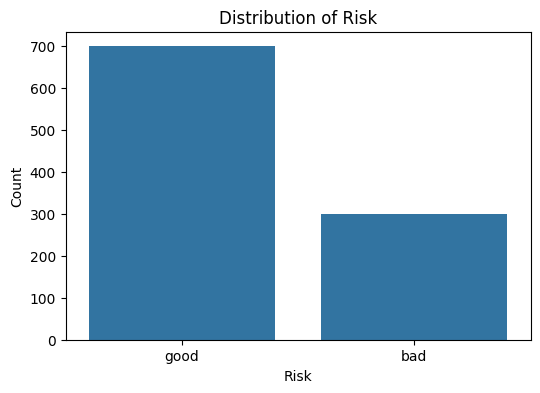

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Risk', data=dataset)
plt.title('Distribution of Risk')
plt.xlabel('Risk')
plt.ylabel('Count')
plt.show()

In [8]:
dataset.isnull().sum()

,0
Unnamed: 0,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,183
Checking account,394
Credit amount,0
Duration,0
Purpose,0


In [9]:
dataset = dataset.drop(columns=['Saving accounts', 'Checking account'])

In [10]:
dataset

,Unnamed: 0,Age,Sex,Job,Housing,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,1169,6,radio/TV,good
1,1,22,female,2,own,5951,48,radio/TV,bad
2,2,49,male,1,own,2096,12,education,good
3,3,45,male,2,free,7882,42,furniture/equipment,good
4,4,53,male,2,free,4870,24,car,bad
...,...,...,...,...,...,...,...,...,...
995,995,31,female,1,own,1736,12,furniture/equipment,good
996,996,40,male,3,own,3857,30,car,good
997,997,38,male,2,own,804,12,radio/TV,good
998,998,23,male,2,free,1845,45,radio/TV,bad


In [11]:
dataset.isnull().sum()

,0
Unnamed: 0,0
Age,0
Sex,0
Job,0
Housing,0
Credit amount,0
Duration,0
Purpose,0
Risk,0


In [12]:
dataset["Risk"].value_counts()

,count
Risk,
good,700
bad,300


In [13]:
dataset.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Credit amount',
       'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [14]:
dataset.drop(columns='Unnamed: 0',inplace=True)

In [15]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Age            1000 non-null   int64 
 1   Sex            1000 non-null   object
 2   Job            1000 non-null   int64 
 3   Housing        1000 non-null   object
 4   Credit amount  1000 non-null   int64 
 5   Duration       1000 non-null   int64 
 6   Purpose        1000 non-null   object
 7   Risk           1000 non-null   object
dtypes: int64(4), object(4)
memory usage: 62.6+ KB


In [16]:
categoricas = ['Sex', 'Housing', 'Purpose', 'Risk']
dataset = pd.get_dummies(dataset, columns=categoricas, drop_first=True)

# Apenas colunas booleanas
bool_cols = dataset.select_dtypes(include='bool').columns
dataset[bool_cols] = dataset[bool_cols].astype(int)

In [17]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Age                          1000 non-null   int64
 1   Job                          1000 non-null   int64
 2   Credit amount                1000 non-null   int64
 3   Duration                     1000 non-null   int64
 4   Sex_male                     1000 non-null   int64
 5   Housing_own                  1000 non-null   int64
 6   Housing_rent                 1000 non-null   int64
 7   Purpose_car                  1000 non-null   int64
 8   Purpose_domestic appliances  1000 non-null   int64
 9   Purpose_education            1000 non-null   int64
 10  Purpose_furniture/equipment  1000 non-null   int64
 11  Purpose_radio/TV             1000 non-null   int64
 12  Purpose_repairs              1000 non-null   int64
 13  Purpose_vacation/others      1000 non-null   int6

In [18]:
dataset["Job"].unique()

array([2, 1, 3, 0])

In [19]:
dataset

,Age,Job,Credit amount,Duration,Sex_male,Housing_own,Housing_rent,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others,Risk_good
0,67,2,1169,6,1,1,0,0,0,0,0,1,0,0,1
1,22,2,5951,48,0,1,0,0,0,0,0,1,0,0,0
2,49,1,2096,12,1,1,0,0,0,1,0,0,0,0,1
3,45,2,7882,42,1,0,0,0,0,0,1,0,0,0,1
4,53,2,4870,24,1,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,31,1,1736,12,0,1,0,0,0,0,1,0,0,0,1
996,40,3,3857,30,1,1,0,1,0,0,0,0,0,0,1
997,38,2,804,12,1,1,0,0,0,0,0,1,0,0,1
998,23,2,1845,45,1,0,0,0,0,0,0,1,0,0,0


a partir daqui vou seguir a pipeline dos anteriores.

In [20]:
y = dataset['Risk_good']
y

,Risk_good
0,1
1,0
2,1
3,1
4,0
...,...
995,1
996,1
997,1
998,0


In [21]:
X = dataset.drop(columns='Risk_good')
X

,Age,Job,Credit amount,Duration,Sex_male,Housing_own,Housing_rent,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
0,67,2,1169,6,1,1,0,0,0,0,0,1,0,0
1,22,2,5951,48,0,1,0,0,0,0,0,1,0,0
2,49,1,2096,12,1,1,0,0,0,1,0,0,0,0
3,45,2,7882,42,1,0,0,0,0,0,1,0,0,0
4,53,2,4870,24,1,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,31,1,1736,12,0,1,0,0,0,0,1,0,0,0
996,40,3,3857,30,1,1,0,1,0,0,0,0,0,0
997,38,2,804,12,1,1,0,0,0,0,0,1,0,0
998,23,2,1845,45,1,0,0,0,0,0,0,1,0,0


In [22]:
print(X.shape, y.shape)

(1000, 14) (1000,)


In [23]:
colunas_originais = X.columns


In [24]:
scaler = StandardScaler()
scaler.fit(X)
X=scaler.transform(X)

X = pd.DataFrame(X, columns=colunas_originais)
print(X)

          Age       Job  Credit amount  Duration  Sex_male  Housing_own  \
0    2.766456  0.146949      -0.745131 -1.236478  0.670280     0.634448   
1   -1.191404  0.146949       0.949817  2.248194 -1.491914     0.634448   
2    1.183312 -1.383771      -0.416562 -0.738668  0.670280     0.634448   
3    0.831502  0.146949       1.634247  1.750384  0.670280    -1.576173   
4    1.535122  0.146949       0.566664  0.256953  0.670280    -1.576173   
..        ...       ...            ...       ...       ...          ...   
995 -0.399832 -1.383771      -0.544162 -0.738668 -1.491914     0.634448   
996  0.391740  1.677670       0.207612  0.754763  0.670280     0.634448   
997  0.215835  0.146949      -0.874503 -0.738668  0.670280     0.634448   
998 -1.103451  0.146949      -0.505528  1.999289  0.670280    -1.576173   
999 -0.751642  0.146949       0.462457  1.999289  0.670280     0.634448   

     Housing_rent  Purpose_car  Purpose_domestic appliances  \
0       -0.466933    -0.712949      

In [25]:
# Cálculo do MI Score
mi_scores = mutual_info_classif(X, y)

# Ranking crescente (menor MI = menos informativa)
mi_ranking = pd.Series(mi_scores, index=X.columns).sort_values(ascending=True)

# Exibir top e bottom features
display(mi_ranking.head(10))   # 10 menos relevantes
display(mi_ranking.tail(10))   # 10 mais relevantes

,0
Job,0.000000
Purpose_car,0.000000
Purpose_education,0.000000
Purpose_domestic appliances,0.000000
Purpose_furniture/equipment,0.000000
Purpose_repairs,0.008938
Credit amount,0.013054
Purpose_vacation/others,0.014628
Age,0.014973
Housing_own,0.018270


,0
Purpose_furniture/equipment,0.000000
Purpose_repairs,0.008938
Credit amount,0.013054
Purpose_vacation/others,0.014628
Age,0.014973
Housing_own,0.018270
Sex_male,0.022030
Purpose_radio/TV,0.026070
Duration,0.028384
Housing_rent,0.039836


In [26]:
percentuais = [0, 0.1, 0.2, 0.3, 0.4, 0.5]
resultados = []

In [ ]:
def run_experimento(modelo_nome, model, X_train, X_val, y_train, y_val, return_preds=False):
    print(f"\nTreinando modelo: {modelo_nome}...")
    tracker = EmissionsTracker()
    tracker.start()
    start_time = time.time()

    try:
        if modelo_nome == 'RNA':
            model.fit(X_train, y_train, epochs=30, batch_size=32, verbose=0)
            y_pred_proba = model.predict(X_val).flatten()
            y_pred = (y_pred_proba > 0.5).astype(int)
        else:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)

            if hasattr(model, "predict_proba"):
                y_pred_proba = model.predict_proba(X_val)[:, 1]
            elif hasattr(model, "decision_function"):
                y_pred_proba = 1 / (1 + np.exp(-model.decision_function(X_val)))
            else:
                y_pred_proba = np.clip(y_pred.astype(float), 0, 1)

    finally:
        emissions_kg = tracker.stop()
        emissions_g = emissions_kg * 1000
        energia = tracker._total_energy.kWh
        tempo = time.time() - start_time

    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, zero_division=0)
    rec = recall_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)
    brier = brier_score_loss(y_val, y_pred_proba)
    auc = roc_auc_score(y_val, y_pred_proba) if len(np.unique(y_val)) == 2 else np.nan

    rga = emissions_g / acc if acc > 0 else float('inf')

    emissions_g = float(f"{emissions_g:.10f}")
    rga = float(f"{rga:.10f}")
    brier = float(f"{brier:.10f}")
    auc = float(f"{auc:.10f}") if not np.isnan(auc) else np.nan

    print(f"{modelo_nome} concluído.")
    print(f"Acurácia: {acc:.4f} | Precisão: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
    print(f"AUC: {auc:.10f} | Brier: {brier:.10f} | RGA: {rga:.10f}")
    print(f"Emissões: {emissions_g:.10f} gCO₂eq | Tempo: {tempo:.4f}s\n")

    if return_preds:
        return (
            acc, prec, rec, f1, brier, auc,
            tempo, emissions_g, energia, rga,
            y_pred, y_pred_proba
        )
    else:
        return acc, prec, rec, f1, brier, auc, tempo, emissions_g, energia, rga


In [ ]:
for p in percentuais:
    print(f"Redução de {int(p*100)}%:")

    n_remove = int(len(mi_ranking) * p)
    cols_reduzido = mi_ranking.index[n_remove:] 
    X_reduz = X[cols_reduzido]

    print(f"Antes: {X.shape[1]} features")
    print(f"Removidas: {n_remove}")
    print(f"Depois: {X_reduz.shape[1]} features")

    X_train, X_val, y_train, y_val = train_test_split(
        X_reduz, y, test_size=0.3, random_state=10
    )

    modelos = {
        "RandomForest": RandomForestClassifier(n_estimators=30, random_state=10),
        "LightGBM": LGBMClassifier(n_estimators=30, random_state=10),
        "RNA": Sequential([
            Dense(64, input_dim=X_train.shape[1], activation='relu'),
            Dense(32, activation='relu'),
            Dense(1, activation='sigmoid')
        ])
    }

    for nome, modelo in modelos.items():
        if nome == "RNA":
            modelo.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

        acc, prec, rec, f1, brier, auc, tempo, em, energia, rga, y_pred, y_prob = run_experimento(
            nome, modelo, X_train, X_val, y_train, y_val, return_preds=True
        )

        f1 = f1_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred)
        rec = recall_score(y_val, y_pred)
        brier = brier_score_loss(y_val, y_prob)
        auc = roc_auc_score(y_val, y_prob)
        rga = em / acc if acc > 0 else float('inf')

        resultados.append([
            nome,
            f"-{int(p*100)}%",
            X_reduz.shape[1],
            acc,
            prec,
            rec,
            f1,
            brier,
            auc,
            tempo,
            energia,
            em,
            rga
        ])

print("Todos os experimentos finalizados!\n")


Redução de 0%:
Antes: 14 features
Removidas: 0
Depois: 14 features


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
[codecarbon WARNING @ 19:04:58] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 19:04:58] [setup] RAM Tracking...
[codecarbon INFO @ 19:04:58] [setup] CPU Tracking...



Treinando modelo: RandomForest...


[codecarbon WARNING @ 19:05:00] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 19:05:00] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 19:05:00] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 19:05:00] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 19:05:00] [setup] GPU Tracking...
[codecarbon INFO @ 19:05:00] No GPU found.
[codecarbon INFO @ 19:05:00] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: global constant
                GPU Tracking Method: Unspecified
            
[codecarbon INFO @ 19:05:00] >>> Tracker's metadata:
[codecarbon INFO @ 19:05:00]   Platf

RandomForest concluído.
Acurácia: 0.6800 | Precisão: 0.7066 | Recall: 0.9015 | F1: 0.7922
AUC: 0.6279772485 | Brier: 0.2137518519 | RGA: 0.0009491270
Emissões: 0.0006454064 gCO₂eq | Tempo: 0.1466s


Treinando modelo: LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 497, number of negative: 203
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000308 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 333
[LightGBM] [Info] Number of data points in the train set: 700, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.710000 -> initscore=0.895384
[LightGBM] [Info] Start training from score 0.895384
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

...

RandomForest concluído.
Acurácia: 0.6467 | Precisão: 0.7029 | Recall: 0.8276 | F1: 0.7602
AUC: 0.5969986288 | Brier: 0.2437552444 | RGA: 0.0010635458
Emissões: 0.0006877596 gCO₂eq | Tempo: 0.1416s


Treinando modelo: LightGBM...
[LightGBM] [Info] Number of positive: 497, number of negative: 203
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000088 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 85
[LightGBM] [Info] Number of data points in the train set: 700, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.710000 -> initscore=0.895384
[LightGBM] [Info] Start training from score 0.895384
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

[codecarbon WARNING @ 19:05:29] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 19:05:29] [setup] RAM Tracking...
[codecarbon INFO @ 19:05:29] [setup] CPU Tracking...
[codecarbon WARNING @ 19:05:29] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 19:05:29] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 19:05:29] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 19:05:29] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 19:05:29] [setup] GPU Tracking...
[codecarbon INFO @ 19:05:29] No GPU found.
[codecarbon INFO @ 19:05:29] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation mo

LightGBM concluído.
Acurácia: 0.6733 | Precisão: 0.6966 | Recall: 0.9163 | F1: 0.7915
AUC: 0.6416637042 | Brier: 0.2097338193 | RGA: 0.0002288839
Emissões: 0.0001541152 gCO₂eq | Tempo: 0.5205s


Treinando modelo: RNA...
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


[codecarbon INFO @ 19:05:35] Energy consumed for RAM : 0.000016 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 19:05:35] Delta energy consumed for CPU with constant : 0.000067 kWh, power : 42.5 W
[codecarbon INFO @ 19:05:35] Energy consumed for All CPU : 0.000067 kWh
[codecarbon INFO @ 19:05:35] 0.000083 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon WARNING @ 19:05:35] The CSV format has changed, backing up old emission file.


RNA concluído.
Acurácia: 0.6867 | Precisão: 0.6912 | Recall: 0.9704 | F1: 0.8074
AUC: 0.6767812706 | Brier: 0.2025991750 | RGA: 0.0420235973
Emissões: 0.0288562034 gCO₂eq | Tempo: 5.6822s

Todos os experimentos finalizados!



In [ ]:
df_resultados = pd.DataFrame(
    resultados,
    columns=[
        "Modelo",
        "Redução",
        "N_Features",
        "Acurácia",
        "Precisão",
        "Recall",
        "F1-Score",
        "Brier",
        "AUC",
        "Tempo (s)",
        "Energia (kWh)",
        "Emissões (gCO₂eq)",
        "RGA"
    ]
)
df_resultados.to_csv(
    "/content/drive/MyDrive/Pesquisa 2/Código/german_credit_data/[REDUÇÃO - CODECARBON]resultados_experimentos[german_credit_data].csv",
    index=False,
    sep=';',
    encoding='utf-8-sig'
)

print("\n✅ Prévia dos resultados:")
display(df_resultados.head())



✅ Prévia dos resultados:


,Modelo,Redução,N_Features,Acurácia,Precisão,Recall,F1-Score,Brier,AUC,Tempo (s),Energia (kWh),Emissões (gCO₂eq),RGA
0,RandomForest,-0%,14,0.680000,0.706564,0.901478,0.792208,0.213752,0.627977,0.146591,1.848104e-06,0.000645,0.000949
1,LightGBM,-0%,14,0.700000,0.716475,0.921182,0.806034,0.203561,0.678330,0.070459,8.275697e-07,0.000289,0.000413
2,RNA,-0%,14,0.706667,0.707581,0.965517,0.816667,0.201804,0.679803,4.950057,7.164403e-05,0.025020,0.035406
3,RandomForest,-10%,13,0.676667,0.713710,0.871921,0.784922,0.215085,0.634909,0.099549,1.235762e-06,0.000432,0.000638
4,LightGBM,-10%,13,0.700000,0.711610,0.935961,0.808511,0.204885,0.667412,0.053061,4.040616e-07,0.000141,0.000202


# AUMENTO DAS FEATURES

In [ ]:
def aumentar_features(df, percent_increase):
    df_new = df.copy()
    epsilon = 1e-6

    # ---------------------- NÍVEL 10% (+1 feature) ----------------------
    if percent_increase >= 10:
        df_new['feat_Credit_per_month'] = df_new['Credit amount'] / (df_new['Duration'] + epsilon)

    # ---------------------- NÍVEL 20% (+2 features total) ----------------------
    if percent_increase >= 20:
        df_new['feat_Age_young'] = (df_new['Age'] < 30).astype(int)

    # ---------------------- NÍVEL 30% (+4 features total) ----------------------
    if percent_increase >= 30:
        df_new['feat_Job_Credit_Interaction'] = df_new['Job'] * df_new['Credit amount']
        df_new['feat_High_Amount'] = (df_new['Credit amount'] > df_new['Credit amount'].median()).astype(int)

    # ---------------------- NÍVEL 40% (+6 features total) ----------------------
    if percent_increase >= 40:
        df_new['feat_Housing_Score'] = df_new['Housing_own'] * 2 + df_new['Housing_rent']
        # Duração ponderada pela idade
        df_new['feat_Duration_Age_Ratio'] = df_new['Duration'] / (df_new['Age'] + epsilon)

    # ---------------------- NÍVEL 50% (+7 features total) ----------------------
    if percent_increase >= 50:
        risk_cols = ['Purpose_education', 'Purpose_repairs', 'Purpose_vacation/others']
        df_new['feat_High_Risk_Purpose'] = df_new[risk_cols].sum(axis=1)

    df_new = df_new.replace([np.inf, -np.inf], np.nan).fillna(0)

    return df_new

In [ ]:
percentuais_aumento = [0.1, 0.2, 0.3, 0.4, 0.5]
resultados_aumento = []

X_original = X.copy()
y_original = y.copy()

for p in percentuais_aumento:
    nivel_percentual = int(p * 100)
    print(f"\n--- Iniciando experimento para AUMENTO de {nivel_percentual}% ---")

    X_aumentado = aumentar_features(X_original, nivel_percentual)

    print(f"Features Originais: {X_original.shape[1]}")
    n_adicionadas = X_aumentado.shape[1] - X_original.shape[1]
    print(f"Features Adicionadas: {n_adicionadas}")
    print(f"Features Totais: {X_aumentado.shape[1]}\n")

    X_train, X_val, y_train, y_val = train_test_split(
        X_aumentado, y_original, test_size=0.3, random_state=10 + nivel_percentual
    )

    print(f"Tamanho de entrada para RNA: {X_train.shape[1]} features")

    modelos = {
        "RandomForest": RandomForestClassifier(n_estimators=30, random_state=10),
        "LightGBM": LGBMClassifier(n_estimators=30, random_state=10),
        "RNA": Sequential([
            Dense(64, input_dim=X_train.shape[1], activation='relu'),
            Dense(32, activation='relu'),
            Dense(1, activation='sigmoid')
        ])
    }
    for nome, modelo in modelos.items():
        if nome == "RNA":
            modelo.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

        acc, prec, rec, f1, brier, auc, tempo, em, energia, rga, y_pred, y_prob = run_experimento(
            nome, modelo, X_train, X_val, y_train, y_val, return_preds=True
        )

        resultados_aumento.append([
            nome,
            f"+{nivel_percentual}%",
            X_aumentado.shape[1],
            acc, prec, rec, f1, brier, auc, tempo, energia, em, rga
        ])

print("\n--- Todos os experimentos de AUMENTO finalizados! ---")

colunas = ["Modelo", "Alteração", "N_Features", "Accuracy", "Precision", "Recall",
            "F1", "Brier", "AUC", "Tempo", "Energia", "EM", "RGA"]

resultados_aumento_df = pd.DataFrame(resultados_aumento, columns=colunas)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
[codecarbon WARNING @ 19:05:35] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 19:05:35] [setup] RAM Tracking...
[codecarbon INFO @ 19:05:35] [setup] CPU Tracking...



--- Iniciando experimento para AUMENTO de 10% ---
Features Originais: 14
Features Adicionadas: 1
Features Totais: 15

Tamanho de entrada para RNA: 15 features

Treinando modelo: RandomForest...


[codecarbon WARNING @ 19:05:35] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 19:05:35] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 19:05:35] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 19:05:35] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 19:05:35] [setup] GPU Tracking...
[codecarbon INFO @ 19:05:35] No GPU found.
[codecarbon INFO @ 19:05:35] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: global constant
                GPU Tracking Method: Unspecified
            
[codecarbon INFO @ 19:05:35] >>> Tracker's metadata:
[codecarbon INFO @ 19:05:35]   Platf

RandomForest concluído.
Acurácia: 0.6433 | Precisão: 0.6707 | Recall: 0.8698 | F1: 0.7574
AUC: 0.6115933642 | Brier: 0.2393851852 | RGA: 0.0007228518
Emissões: 0.0004650347 gCO₂eq | Tempo: 0.1104s


Treinando modelo: LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 508, number of negative: 192
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000110 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 564
[LightGBM] [Info] Number of data points in the train set: 700, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.725714 -> initscore=0.972986
[LightGBM] [Info] Start training from score 0.972986
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

[codecarbon INFO @ 19:05:35]   Platform system: Linux-6.6.113+-x86_64-with-glibc2.35
[codecarbon INFO @ 19:05:35]   Python version: 3.12.12
[codecarbon INFO @ 19:05:35]   CodeCarbon version: 3.2.3
[codecarbon INFO @ 19:05:35]   Available RAM : 12.671 GB
[codecarbon INFO @ 19:05:35]   CPU count: 2 thread(s) in 1 physical CPU(s)
[codecarbon INFO @ 19:05:35]   CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon INFO @ 19:05:35]   GPU count: None
[codecarbon INFO @ 19:05:35]   GPU model: None
[codecarbon INFO @ 19:05:35] Emissions data (if any) will be saved to file /content/emissions.csv


...

RandomForest concluído.
Acurácia: 0.6667 | Precisão: 0.6923 | Recall: 0.8769 | F1: 0.7738
AUC: 0.6316971917 | Brier: 0.2202666667 | RGA: 0.0013107611
Emissões: 0.0008738407 gCO₂eq | Tempo: 0.2086s


Treinando modelo: LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 505, number of negative: 195
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000418 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1033
[LightGBM] [Info] Number of data points in the train set: 700, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.721429 -> initscore=0.951559
[LightGBM] [Info] Start training from score 0.951559
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[codecarbon WARNING @ 19:05:57] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 19:05:57] [setup] RAM Tracking...
[codecarbon INFO @ 19:05:57] [setup] CPU Tracking...
[codecarbon WARNING @ 19:05:57] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 19:05:57] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 19:05:57] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 19:05:57] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 19:05:57] [setup] GPU Tracking...
[codecarbon INFO @ 19:05:57] No GPU found.
[codecarbon INFO @ 19:05:57] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation mo

LightGBM concluído.
Acurácia: 0.6433 | Precisão: 0.6760 | Recall: 0.8667 | F1: 0.7596
AUC: 0.6121123321 | Brier: 0.2339820474 | RGA: 0.0003665577
Emissões: 0.0002358188 gCO₂eq | Tempo: 0.0554s


Treinando modelo: RNA...
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


[codecarbon INFO @ 19:06:03] Energy consumed for RAM : 0.000016 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 19:06:03] Delta energy consumed for CPU with constant : 0.000069 kWh, power : 42.5 W
[codecarbon INFO @ 19:06:03] Energy consumed for All CPU : 0.000069 kWh
[codecarbon INFO @ 19:06:03] 0.000085 kWh of electricity and 0.000000 L of water were used since the beginning.


RNA concluído.
Acurácia: 0.6567 | Precisão: 0.6840 | Recall: 0.8769 | F1: 0.7685
AUC: 0.5436385836 | Brier: 0.2498490226 | RGA: 0.0454414452
Emissões: 0.0298398824 gCO₂eq | Tempo: 5.8799s


--- Todos os experimentos de AUMENTO finalizados! ---


In [32]:
df_resultados = pd.DataFrame(
    resultados_aumento,
    columns=[
        "Modelo",
        "Redução",
        "N_Features",
        "Acurácia",
        "Precisão",
        "Recall",
        "F1-Score",
        "Brier",
        "AUC",
        "Tempo (s)",
        "Energia (kWh)",
        "Emissões (gCO₂eq)",
        "RGA"
    ]
)


caminho_saida = "/content/drive/MyDrive/Pesquisa 2/Código/german_credit_data/[AUMENTO - CODECARBON]resultados_experimentos[german_credit_data].csv"
df_resultados.to_csv(
    caminho_saida,
    index=False,
    sep=';',
    encoding='utf-8-sig'
)

print(f"Resultados salvos em: {caminho_saida}")
print("\n✅ Prévia dos resultados:")
display(df_resultados.head())

Resultados salvos em: /content/drive/MyDrive/Pesquisa 2/Código/german_credit_data/[AUMENTO - CODECARBON]resultados_experimentos[german_credit_data].csv

✅ Prévia dos resultados:


,Modelo,Redução,N_Features,Acurácia,Precisão,Recall,F1-Score,Brier,AUC,Tempo (s),Energia (kWh),Emissões (gCO₂eq),RGA
0,RandomForest,+10%,15,0.643333,0.670683,0.869792,0.757370,0.239385,0.611593,0.110431,1.331614e-06,0.000465,0.000723
1,LightGBM,+10%,15,0.663333,0.674330,0.916667,0.777042,0.231599,0.636550,0.047154,5.110172e-07,0.000178,0.000269
2,RNA,+10%,15,0.633333,0.662698,0.869792,0.752252,0.242936,0.588204,4.357789,6.320287e-05,0.022072,0.034851
3,RandomForest,+20%,16,0.686667,0.719512,0.876238,0.790179,0.219478,0.620125,0.117894,1.479072e-06,0.000517,0.000752
4,LightGBM,+20%,16,0.703333,0.721569,0.910891,0.805252,0.207487,0.660639,0.050832,4.282852e-07,0.000150,0.000213
